<a href="https://colab.research.google.com/github/Chen-Terese/Masters-Thesis/blob/main/External_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing the required libraries**

In [1]:
import os, random, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, Model
from tensorflow.keras.models import load_model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
random.seed(42)

# **Loading the dataset**

In [4]:
DATA_ROOT = "/content/drive/MyDrive/OriginalDataset"
LABEL_MAP = {
    "NonDemented":      "CN",
    "MildDemented":     "AD",
    "ModerateDemented": "AD",
}

TARGET_PER_CLASS = 100   # 100 CN + 100 AD = 200 total
IMG_SIZE = 224
THRESHOLD = 0.1


# **Custom SOM Layer/ Loading the Hybrid Model**

In [5]:
class SOMLayer(tf.keras.layers.Layer):
    """
    Self-Organizing Map layer with neighbourhood regularisation.

    Computes Euclidean distances from the input to every prototype, returns
    those distances to the classification head, and simultaneously adds a
    soft neighbourhood loss that encourages topological ordering.
    """
    def __init__(self, map_size=(10, 10), som_lambda=0.01, **kwargs):
        super(SOMLayer, self).__init__(**kwargs)
        self.map_size   = map_size
        self.n_nodes    = map_size[0] * map_size[1]
        self.som_lambda = som_lambda

    def build(self, input_shape):
        self.prototypes = self.add_weight(
            name='prototypes',
            shape=(self.n_nodes, input_shape[-1]),
            initializer=tf.keras.initializers.GlorotUniform(seed=42),
            trainable=True
        )
        super(SOMLayer, self).build(input_shape)

    def call(self, inputs):
        diff      = tf.expand_dims(inputs, axis=1) - self.prototypes
        distances = tf.math.sqrt(tf.reduce_sum(tf.square(diff), axis=-1) + 1e-8)

        # Neighbourhood loss: pull input toward its closest prototype
        bmu_idx        = tf.argmin(distances, axis=1)
        bmu_protos     = tf.gather(self.prototypes, bmu_idx)
        neighbour_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(inputs - bmu_protos), axis=-1)
        )
        self.add_loss(self.som_lambda * neighbour_loss)

        return distances

In [6]:
print("Loading model...")
hybrid_som_model = load_model(
    '/content/drive/MyDrive/hybrid_som_model_final.h5',
    custom_objects={"SOMLayer": SOMLayer},
    compile=False
)
print("✅ Model loaded!")

Loading model...
✅ Model loaded!


In [7]:
#Sving the Figures
SAVE_DIR = '/content/drive/MyDrive/Thesis_Results_Final_One'
os.makedirs(SAVE_DIR, exist_ok=True)

def save_thesis_plot(filename):
    path = os.path.join(SAVE_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"Saved: {path}")

In [8]:
#Mapping and picking a balanced number across CN and AD samples
cn_pool, ad_pool = [], []

for folder_name, label in LABEL_MAP.items():
    folder_path = os.path.join(DATA_ROOT, folder_name)
    if not os.path.isdir(folder_path):
        print(f"WARNING: not found — {folder_path}")
        continue
    files = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    print(f"{folder_name}: {len(files)} images → {label}")
    if label == "CN":
        cn_pool.extend(files)
    else:
        ad_pool.extend(files)

random.shuffle(cn_pool)
random.shuffle(ad_pool)

n_cn = min(TARGET_PER_CLASS, len(cn_pool))
n_ad = min(TARGET_PER_CLASS, len(ad_pool))

sample = (
    [(p, "CN") for p in cn_pool[:n_cn]] +
    [(p, "AD") for p in ad_pool[:n_ad]]
)
random.shuffle(sample)
print(f"\nFinal sample: {len(sample)} images ({n_cn} CN, {n_ad} AD)")

NonDemented: 3204 images → CN
MildDemented: 896 images → AD
ModerateDemented: 64 images → AD

Final sample: 200 images (100 CN, 100 AD)


In [9]:
def preprocess_jpg(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img, dtype=np.float32)
    return preprocess_input(arr)


## **Evaluation**

In [10]:
y_true, y_pred, y_prob, records = [], [], [], []

for i, (path, true_label) in enumerate(sample):
    processed = preprocess_jpg(path)
    inp = tf.expand_dims(processed, 0)

    # Single axial view duplicated across all 3 inputs
    preds   = hybrid_som_model.predict([inp, inp, inp], verbose=0)
    prob_ad = float(preds[0][0])
    pred_label = "AD" if prob_ad >= THRESHOLD else "CN"

    y_true.append(0 if true_label == "AD" else 1)
    y_pred.append(0 if pred_label == "AD" else 1)
    y_prob.append(prob_ad)

    records.append({
        "file": os.path.basename(path),
        "true_label": true_label,
        "predicted_label": pred_label,
        "ad_probability": round(prob_ad, 4),
        "correct": true_label == pred_label
    })

    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(sample)} done...")

y_true = np.array(y_true)
y_pred = np.array(y_pred)

  25/200 done...
  50/200 done...
  75/200 done...
  100/200 done...
  125/200 done...
  150/200 done...
  175/200 done...
  200/200 done...



──Kaggle EXTERNAL VALIDATION REPORT (threshold = 0.10) ──
              precision    recall  f1-score   support

          AD       0.79      0.26      0.39       100
          CN       0.56      0.93      0.70       100

    accuracy                           0.59       200
   macro avg       0.67      0.59      0.54       200
weighted avg       0.67      0.59      0.54       200

Saved: /content/drive/MyDrive/Thesis_Results_Final_One/Figure_7_External_Validation_Confusion_Matrix.png


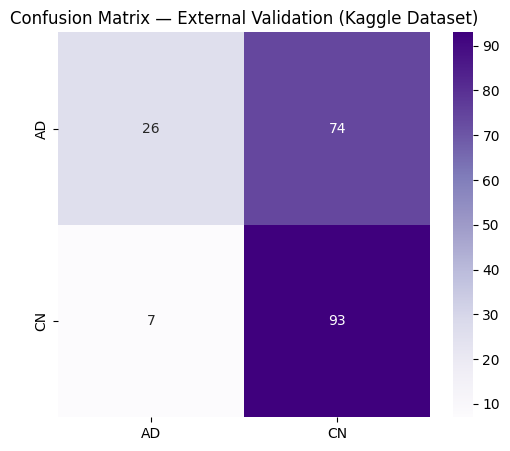

In [11]:
print("\n──Kaggle EXTERNAL VALIDATION REPORT (threshold = 0.10) ──")
print(classification_report(y_true, y_pred, target_names=["AD", "CN"]))

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True, fmt='d', cmap='Purples',
    xticklabels=["AD", "CN"],
    yticklabels=["AD", "CN"]
)
plt.title("Confusion Matrix — External Validation (Kaggle Dataset)")
save_thesis_plot('Figure_7_External_Validation_Confusion_Matrix.png')
plt.show()

In [12]:
import os
for root, dirs, files in os.walk("/content/OriginalDataset"):
    print(root, "→", dirs[:5] if dirs else f"{len(files)} files")
    break  # just show top level first

In [13]:
for root, dirs, files in os.walk("/content/OriginalDataset"):
    print(root)
    if root.count('/') > 4:  # stop after a few levels
        break


In [14]:
results_df = pd.DataFrame(records)
results_path = '/content/drive/MyDrive/external_validation_predictions.csv'
results_df.to_csv(results_path, index=False)
print(f"\nPer-image predictions saved to: {results_path}")
print(f"Overall accuracy: {results_df['correct'].mean()*100:.1f}%")


Per-image predictions saved to: /content/drive/MyDrive/external_validation_predictions.csv
Overall accuracy: 59.5%


Saved: /content/drive/MyDrive/Thesis_Results_Final_One/Figure_8_External_Validation_ROC.png


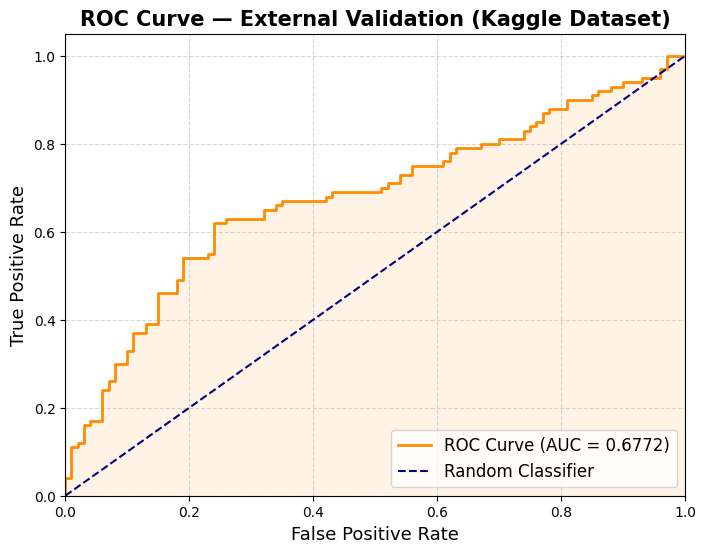


External Validation AUC: 0.6772
ADNI Test Set AUC:       0.8300
AUC Drop:                0.1528


In [15]:
from sklearn.metrics import roc_curve, auc

y_prob = np.array(y_prob)

fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=0)  # pos_label=0 because AD=0
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — External Validation (Kaggle Dataset)', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
save_thesis_plot('Figure_8_External_Validation_ROC.png')
plt.show()
print(f"\nExternal Validation AUC: {roc_auc:.4f}")
print(f"ADNI Test Set AUC:       0.8300")
print(f"AUC Drop:                {0.8300 - roc_auc:.4f}")